#  Analyse Exploratoire des Données (EDA)

## Contexte Business
Nous travaillons pour une entreprise SaaS avec 10 000 clients. L'objectif est de construire un système intelligent de rétention client capable d'anticiper les résiliations et d'évaluer l'impact financier.

## Nos 2 Problématiques

### Problématique 1 — Classification (obligatoire)
**Question :** Quel client va résilier son abonnement ?
**Variable cible :** `churn` (0 = reste, 1 = part)
**Intérêt business :** Prioriser les actions de rétention marketing

### Problématique 2 — Régression (points bonus)
**Question :** Combien d'argent risque-t-on de perdre ?
**Variable cible :** `revenue_at_risk = total_revenue × churn`
**Intérêt business :** Prioriser les clients à forte valeur financière

## Questions auxquelles l'EDA va répondre
1. Qui sont les clients qui churnent ?
2. Quels comportements annoncent un départ ?
3. Quelles variables sont les plus corrélées au churn ?
4. Quels segments sont les plus à risque financièrement ?
5. Y a-t-il des valeurs manquantes ou des outliers à traiter ?


## PARTIE 1 — Exploration générale des données


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/customer_churn_business_dataset.csv')

## Premier regard sur les données

On affiche 10 lignes aléatoires du dataset.

Objectif : vérifier que les données sont bien chargées et 
comprendre la structure du tableau :

- Quelles colonnes existent ?
- Quels types de valeurs ?
- On remarque déjà que `complaint_type` a des valeurs `NaN`

In [3]:
df.sample(10)

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
1799,CUST_01800,Male,29,Australia,Berlin,Individual,36,Web,Yearly,23,...,24.238619,Service,4.0,0,0.24,0.43,5,Satisfied,0,0
6346,CUST_06347,Female,58,Canada,Sydney,Individual,38,Referral,Quarterly,22,...,40.737280,Billing,4.0,1,0.44,0.06,4,Neutral,1,0
6149,CUST_06150,Female,66,Germany,Sydney,Individual,28,Referral,Monthly,26,...,9.890689,Technical,4.0,0,0.29,0.16,-11,Satisfied,0,0
530,CUST_00531,Male,22,Canada,Dhaka,Individual,16,Referral,Monthly,4,...,35.260115,Technical,2.0,1,0.67,0.34,41,Unsatisfied,0,1
1765,CUST_01766,Female,19,Australia,Dhaka,Individual,22,Mobile,Monthly,31,...,16.295094,NaN,4.0,1,0.90,0.09,21,Satisfied,0,1
1169,CUST_01170,Male,19,Germany,Dhaka,Individual,30,Referral,Quarterly,19,...,34.664559,Service,4.0,0,0.77,0.05,-18,Satisfied,1,0
3404,CUST_03405,Male,48,Australia,New York,SME,32,Mobile,Quarterly,0,...,41.249052,NaN,2.0,0,0.79,0.01,-16,Satisfied,0,1
7780,CUST_07781,Female,30,Canada,London,Individual,22,Web,Yearly,18,...,33.364745,NaN,2.0,0,0.23,0.26,36,Satisfied,1,1
6035,CUST_06036,Male,53,USA,Dhaka,Individual,58,Mobile,Monthly,10,...,17.997986,Service,5.0,0,0.30,0.45,-20,Satisfied,2,0
942,CUST_00943,Female,56,USA,Toronto,Individual,11,Referral,Monthly,22,...,17.240608,Technical,2.0,0,0.32,0.10,61,Satisfied,1,0


## Dimensions du dataset

On retourne un tuple (lignes, colonnes) :
- **10 000 lignes** = 10 000 clients
- **32 colonnes** = 32 variables par client

C'est un dataset de taille moyenne, suffisant pour entraîner 
des modèles de Machine Learning fiables.

In [4]:
print(f"Nombre de ligne : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de ligne : 10000
Nombre de colonnes : 32


## Types des colonnes

On affiche le type de chaque colonne :
- **int64** = nombre entier (ex: age, churn)
- **float64** = nombre décimal (ex: monthly_fee, nps_score)
- **object** = texte / catégorie (ex: gender, country)

Cette étape est importante car les modèles de Machine Learning ne comprennent que des chiffres. Les colonnes "object" devront être converties en chiffres lors du preprocessing.

In [5]:
df.dtypes

customer_id                object
gender                     object
age                         int64
country                    object
city                       object
customer_segment           object
tenure_months               int64
signup_channel             object
contract_type              object
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method             object
payment_failures            int64
discount_applied           object
price_increase_last_3m     object
support_tickets             int64
avg_resolution_time       float64
complaint_type             object
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   int64
survey_respons

## Vérification des doublons

**Résultat : 0 doublon** 
Les données sont propres sur ce point, rien à supprimer.

In [6]:
df.duplicated().sum()

np.int64(0)

## Valeurs manquantes

`df.isnull().sum()` compte le nombre de valeurs vides par colonne.

**Résultat :**
- Toutes les colonnes : 0 valeur manquante 
- **complaint_type : 2045 valeurs manquantes** 

Pourquoi complaint_type a des manquants ?
Logique métier : un client qui n'a jamais fait de plainte n'a pas de type de plainte. Ce n'est pas une erreur,  c'est une information en soi.

**Décision :** On remplacera ces manquants par "No_Complaint" lors du preprocessing.

In [7]:
df.isnull().sum()

customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: i

## Statistiques descriptives

On affiche pour chaque colonne numérique :
- **count** : nombre de valeurs
- **mean** : moyenne
- **std** : écart-type (dispersion des valeurs)
- **min / max** : valeurs minimale et maximale
- **25%, 50%, 75%** : quartiles

Points importants observés :
- `churn` : moyenne = 0.102 → seulement 10.2% de churners 
- `nps_score` (C'est une mesure de satisfaction client) : va de -100 à +100 (valeurs négatives normales)
- `total_revenue` : très étalé de 10€ à 5900€
- `last_login_days_ago` : max = 80 jours (clients très inactifs)

In [8]:
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


## Colonnes catégorielles

On identifie les 12 colonnes de type texte (object). Ce sont ces colonnes qu'on devra encoder en chiffres lors du preprocessing car le Machine Learning ne comprend que des nombres.

In [9]:
df.select_dtypes(include='object').columns.tolist()

['customer_id',
 'gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']


## PARTIE 2 — Analyses spécifiques à la Classification


## Distribution de la variable cible — Churn

On analyse la répartition de notre variable cible `churn` :
- **8 979 clients restent** (89.8%)
- **1 021 clients partent** (10.2%)

Le dataset est très déséquilibré !

Problème : Un modèle qui prédit "le client reste" pour TOUS les clients aurait 89.8% d'accuracy, 
même s'il n'apprend rien.

Solution : on utilisera `class_weight='balanced'` dans nos modèles pour forcer le modèle à accorder plus d'importance aux churners.

On privilégiera aussi des métriques adaptées :
- **Recall** : détecte-t-on bien les churners ?
- **F1-Score** : équilibre entre precision et recall
- **ROC-AUC** : performance globale du modèle

In [10]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print("Distribution du Churn :")
print(f"  Clients qui restent  (0) : {churn_counts[0]} ({churn_pct[0]:.1f}%)")
print(f"  Clients qui partent  (1) : {churn_counts[1]} ({churn_pct[1]:.1f}%)")

Distribution du Churn :
  Clients qui restent  (0) : 8979 (89.8%)
  Clients qui partent  (1) : 1021 (10.2%)


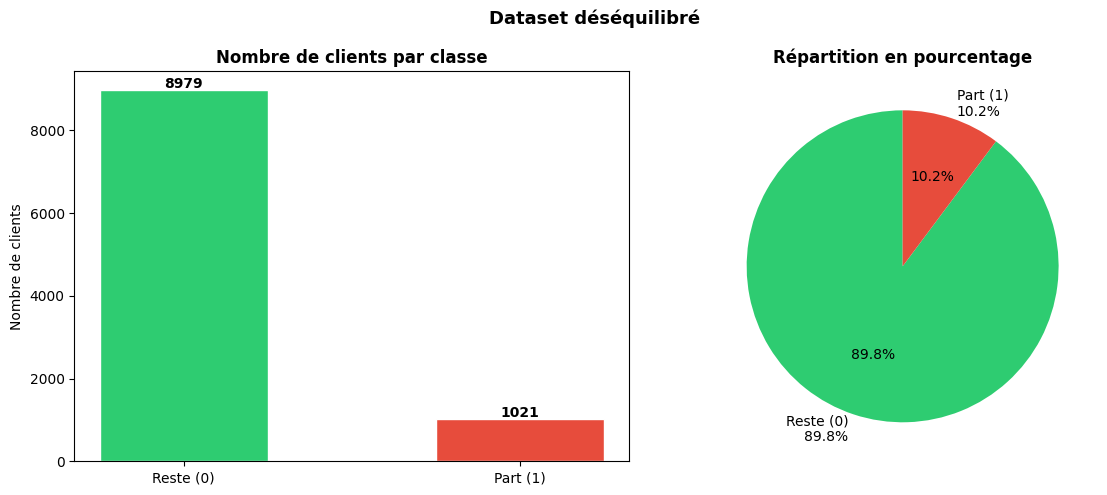

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart (gauche)
axes[0].bar(['Reste (0)', 'Part (1)'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Nombre de clients par classe', fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart (droite)
axes[1].pie(churn_counts.values,
            labels=['Reste (0)\n89.8%', 'Part (1)\n10.2%'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Répartition en pourcentage', fontweight='bold')

plt.suptitle('Dataset déséquilibré', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

## Analyse du Revenu à Risque

Maintenant qu'on sait que 10.2% des clients churnent, on cherche à quantifier l'impact financier pour l'entreprise.

**Résultats :**
- Revenu moyen des clients qui **restent** : **1 081€**
- Revenu moyen des clients qui **partent** : **845€**
- Revenu total à risque : **862,640€**

Les churners ont un revenu moyen plus faible que les non-churners — ce sont souvent des clients récents (tenure faible) avec des abonnements moins élevés.

**Implication** : même si le revenu moyen par churner est plus faible, la masse de 862 640€ justifie pleinement la Problématique 2 (régression).

In [12]:

# ANALYSE DU REVENU À RISQUE

# Revenu moyen par groupe churn

# Divise le dataset en 2 groupes, Groupe 0 : clients qui restent, Groupe 1 : clients qui partent,
revenu_par_churn = df.groupby('churn')['total_revenue'].mean() 

print(" Revenu moyen :")
print(f"  Clients qui restent  (0) : {revenu_par_churn[0]:.0f}€") #Accède à la moyenne des churn=0
print(f"  Clients qui partent  (1) : {revenu_par_churn[1]:.0f}€") #Accède à la moyenne des churn=1


# Revenu total à risque estimé
revenu_total_risque = df[df['churn'] == 1]['total_revenue'].sum()
print(f"\n Revenu total à risque : {revenu_total_risque:,}€")
#Formate le nombre :.0f = 0 décimales Exemple : 1083.456 → 1083

 Revenu moyen :
  Clients qui restent  (0) : 1081€
  Clients qui partent  (1) : 845€

 Revenu total à risque : 862,640€


## Taux de churn par variable catégorielle

On calcule le taux de churn moyen pour chaque modalité. La ligne pointillée = moyenne globale (10.2%).

Insights majeurs :
- `customer_segment` : Enterprise (9.4%), Individual (10.0%), SME (10.9%)
  Les écarts sont faibles — aucun segment ne se démarque fortement
- `country` Australia : **11.5%** légèrement au-dessus de la moyenne
- `survey_response` Unsatisfied : **11.1%** légèrement au-dessus
- `contract_type`, `signup_channel`, `payment_method` : tous entre 9% et 11%
  → Aucune variable catégorielle ne présente de signal discriminant fort

Conclusion : les variables numériques (csat_score, payment_failures, tenure_months) 
sont bien plus prédictives que les variables catégorielles pour anticiper le churn.

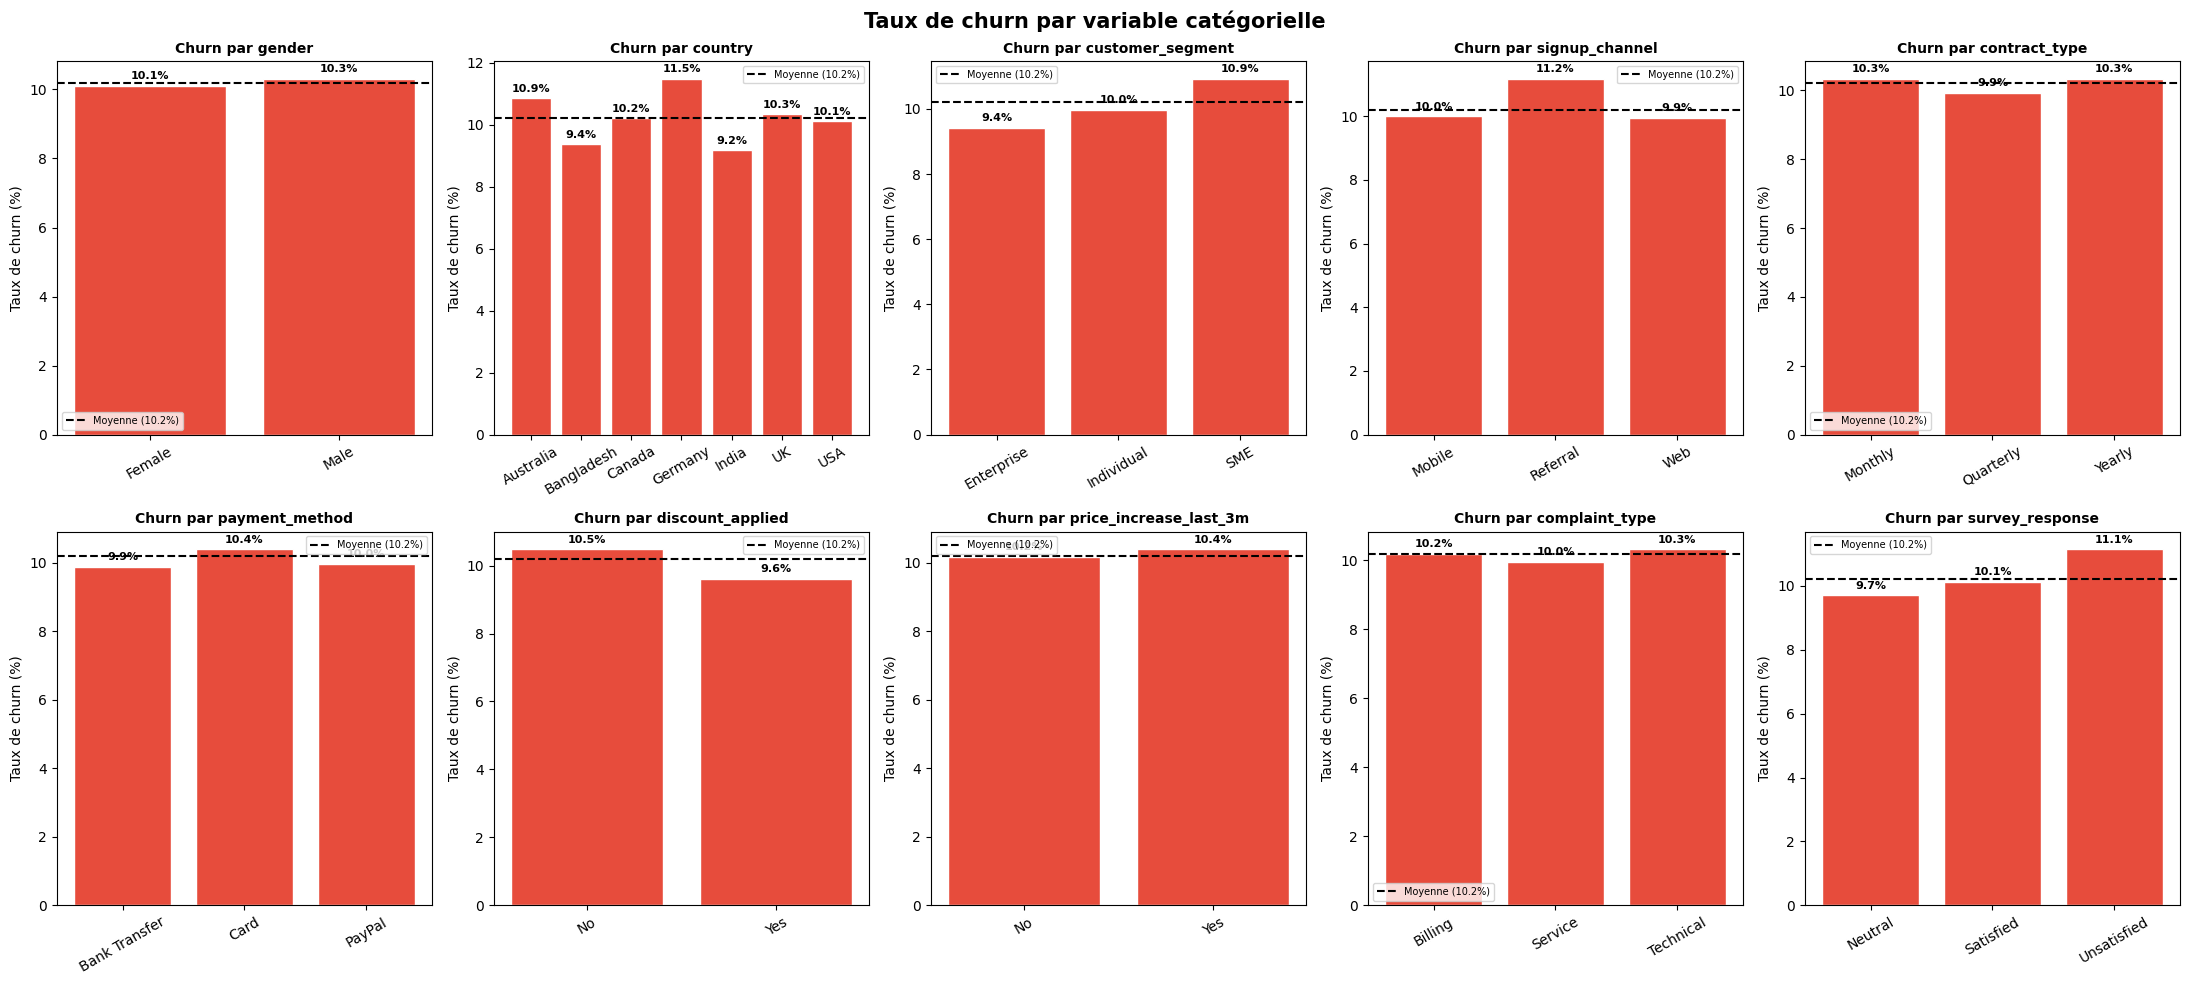

In [13]:
# CHURN PAR VARIABLE CATÉGORIELLE

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

cols_cat = ['gender', 'country', 'customer_segment', 'signup_channel', 
            'contract_type', 'payment_method', 'discount_applied',
            'price_increase_last_3m', 'complaint_type', 'survey_response']

for i, col in enumerate(cols_cat):
    # Taux de churn moyen par catégorie
    churn_rate = df.groupby(col)['churn'].mean() * 100
    
    bars = axes[i].bar(churn_rate.index, 
                       churn_rate.values,
                       color='#e74c3c', 
                       edgecolor='white')
    axes[i].set_title(f'Churn par {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=10.2, color='black', linestyle='--', 
                    label='Moyenne (10.2%)')
    axes[i].legend(fontsize=7)
    
    # Afficher les % sur les barres
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 0.2, f'{v:.1f}%', 
                    ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Taux de churn par variable catégorielle', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribution des variables numériques selon le churn

On superpose les distributions des clients qui restent (vert) 
et des clients qui partent (rouge) pour chaque variable.

Insights clés :
- `tenure_months` : les churners sont concentrés sur 0-10 mois
  → Les nouveaux clients partent plus facilement
- `payment_failures` : les churners ont proportionnellement plus d'échecs (1-3)
  → Signal de friction financière
- `csat_score` : les churners sont surreprésentés aux scores bas (1.5-2)
  → Satisfaction faible = signal de départ
- `monthly_fee`, `support_tickets`, `nps_score`, `last_login_days_ago`, `usage_growth_rate` :
  distributions très similaires entre churners et non-churners
  → Ces variables seules ne discriminent pas fortement le churn

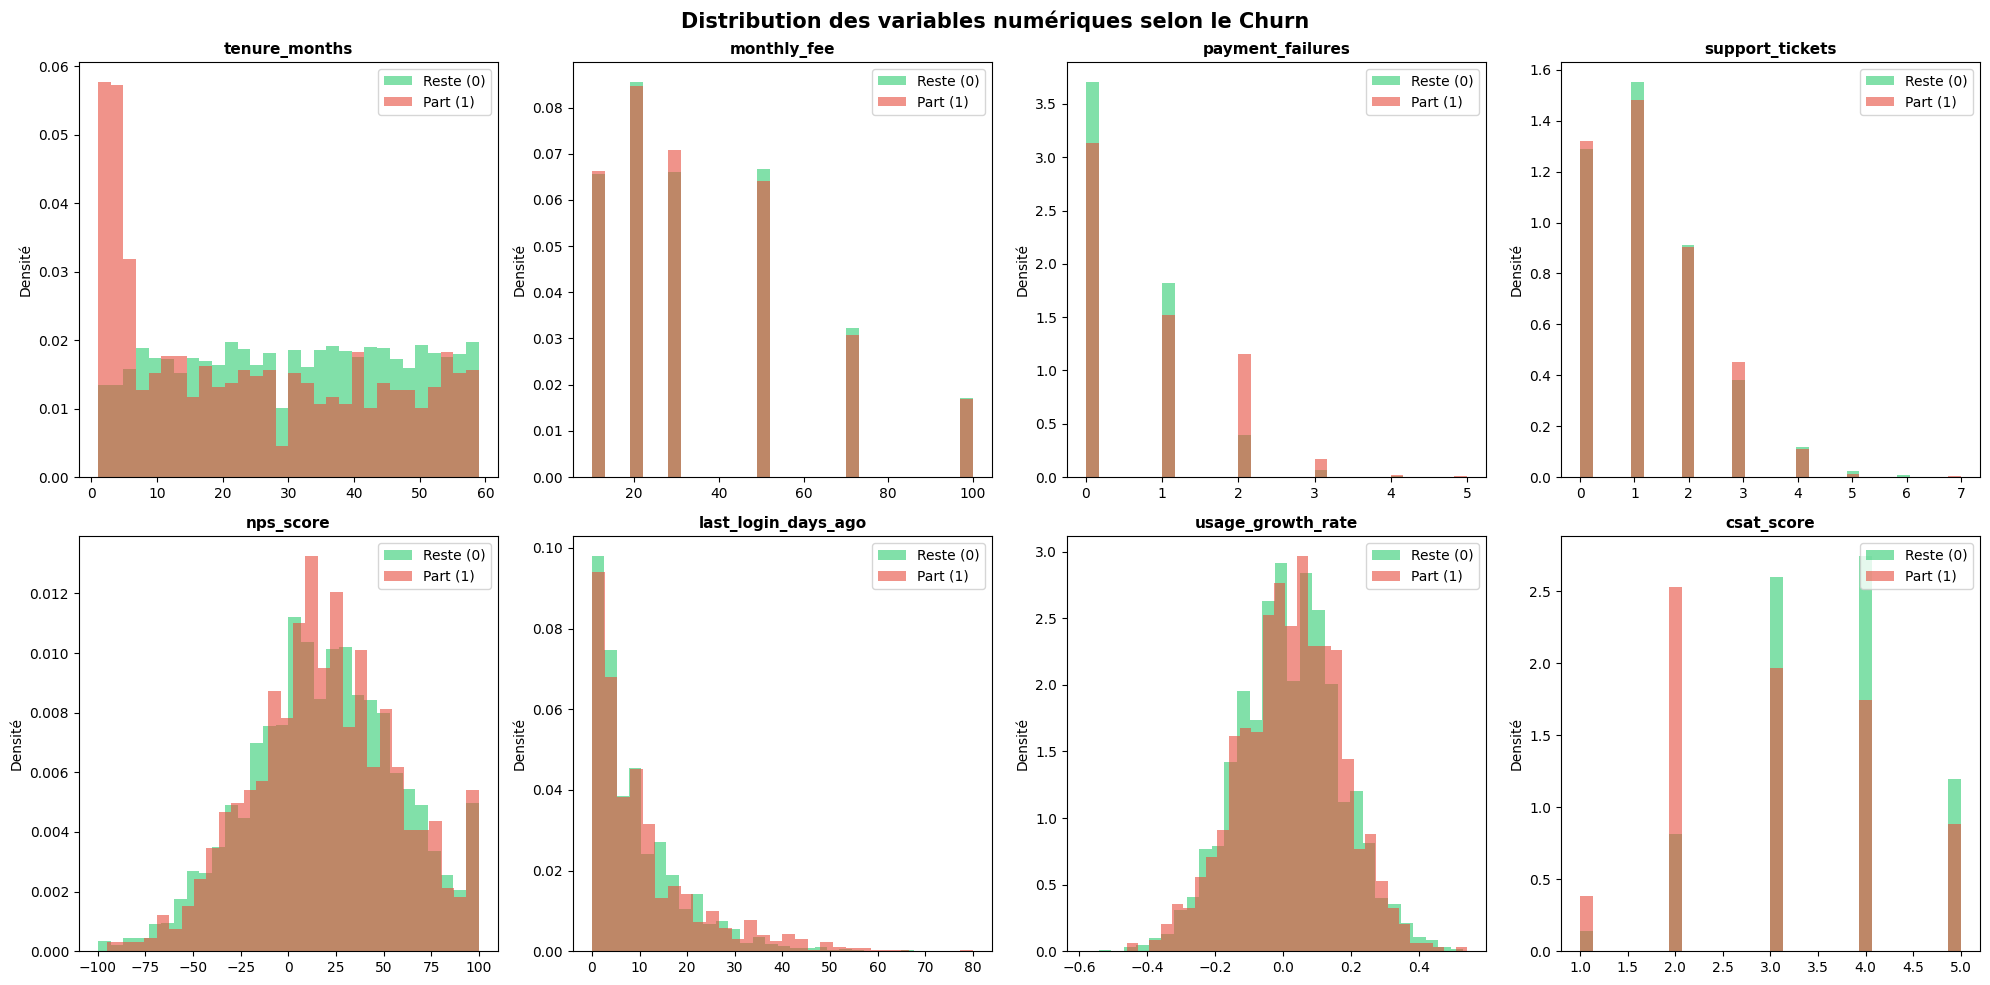

In [14]:

# CHURN PAR VARIABLE NUMÉRIQUE

cols_num_importantes = ['tenure_months', 'monthly_fee', 
                        'payment_failures', 'support_tickets',
                        'nps_score', 'last_login_days_ago',
                        'usage_growth_rate', 'csat_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_num_importantes):
    # Clients qui restent vs qui partent
    reste = df[df['churn'] == 0][col]
    part = df[df['churn'] == 1][col]
    
    axes[i].hist(reste, bins=30, alpha=0.6, 
                 color='#2ecc71', label='Reste (0)', density=True)
    axes[i].hist(part, bins=30, alpha=0.6, 
                 color='#e74c3c', label='Part (1)', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densité')
    axes[i].legend()

plt.suptitle('Distribution des variables numériques selon le Churn', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Matrice de corrélation

La heatmap montre les corrélations entre toutes les variables 
numériques. Une corrélation va de -1 à +1 :
- **+1** : quand une variable augmente, l'autre aussi
- **-1** : quand une variable augmente, l'autre diminue
- **0** : aucun lien entre les deux variables

Corrélations avec le churn :
- `csat_score` : **-0.16** → satisfaction basse = plus de churn
- `tenure_months` : **-0.12** → ancienneté haute = moins de churn
- `monthly_logins` : **-0.10** → peu de connexions = plus de churn
- `payment_failures` : **+0.11** → échecs = plus de churn

Corrélations entre variables :
- `monthly_fee` ↔ `total_revenue` : **+0.71** 
  Ces deux variables sont très liées → attention à la redondance
- `tenure_months` ↔ `total_revenue` : **+0.59**
  Logique : plus on est ancien, plus on a payé au total

Les corrélations faibles avec le churn confirment que le Machine 
Learning est nécessaire — le churn dépend de combinaisons 
complexes de variables, pas d'une seule.

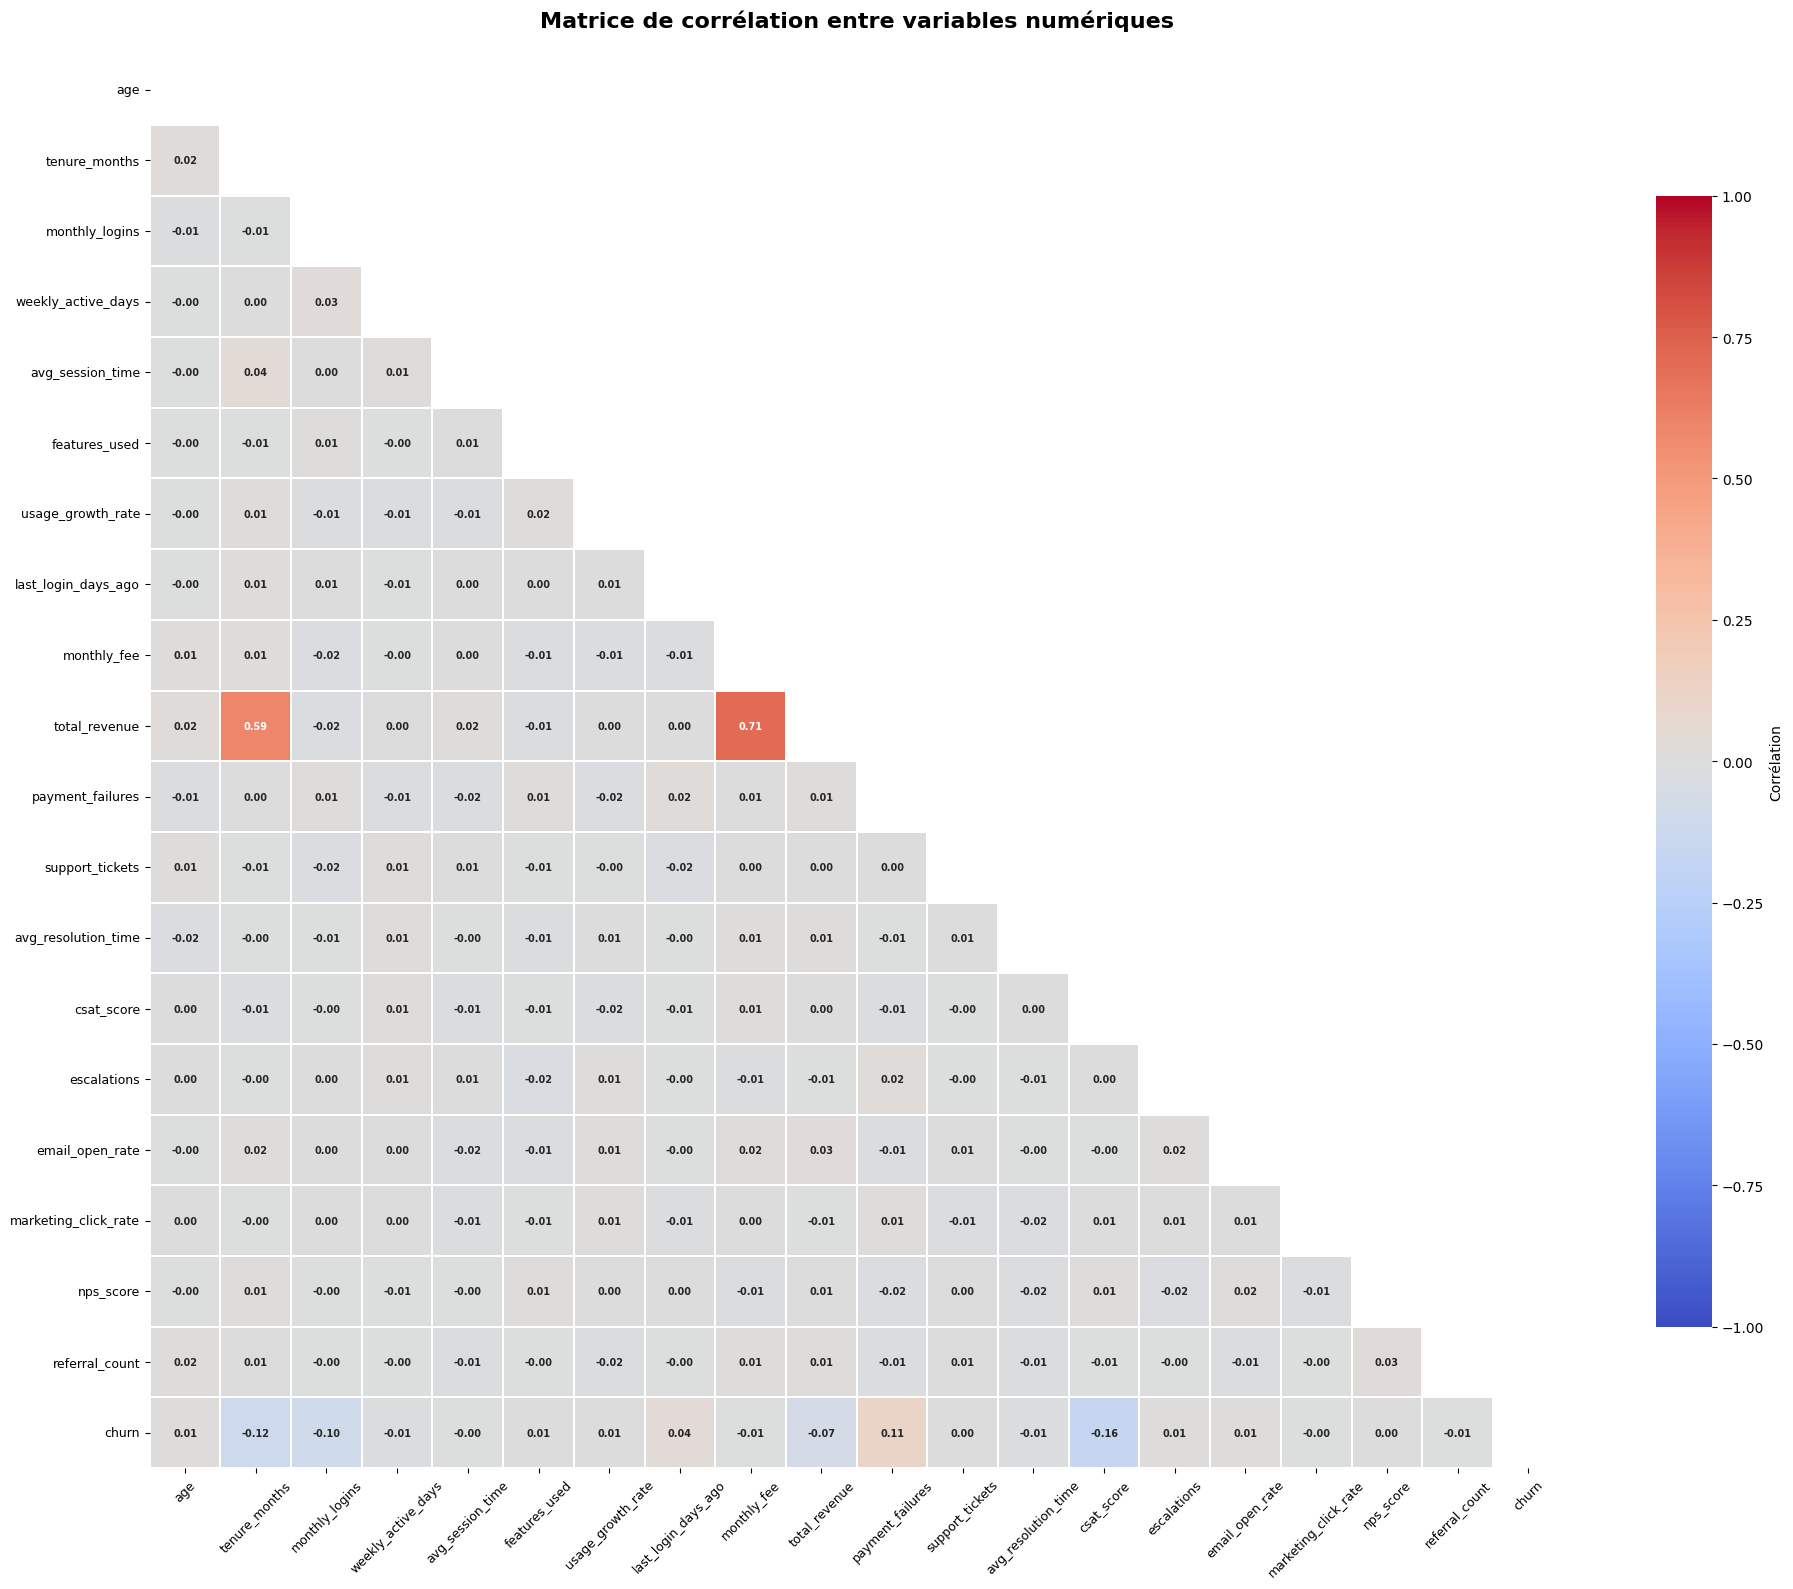

In [15]:
# HEATMAP DES CORRÉLATIONS

cols_corr = ['age', 'tenure_months', 'monthly_logins',
             'weekly_active_days', 'avg_session_time',
             'features_used', 'usage_growth_rate',
             'last_login_days_ago', 'monthly_fee',
             'total_revenue', 'payment_failures',
             'support_tickets', 'avg_resolution_time',
             'csat_score', 'escalations', 'email_open_rate',
             'marketing_click_rate', 'nps_score', 
             'referral_count', 'churn']

corr_matrix = df[cols_corr].corr()

# Masque triangle supérieur pour plus de lisibilité
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.3,
            linecolor='white',
            annot_kws={'size': 7, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation'},
            ax=ax)

ax.set_title('Matrice de corrélation entre variables numériques',
             fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

## Détection des outliers — Boxplots

Un boxplot montre la distribution d'une variable :
- La boîte = 50% des données (entre 25% et 75%)
- La ligne noire = médiane (valeur du milieu)
- Les cercles = outliers (valeurs extrêmes)

Observations :
- `total_revenue` : outliers jusqu'à 5900€ → gros clients réels
- `last_login_days_ago` : outliers jusqu'à 80 jours → inactifs
- `payment_failures` : outliers à 4-5 → très mauvais payeurs
- `avg_resolution_time` : outliers jusqu'à 60h → tickets très longs
- `nps_score` : outliers à -100 → clients très insatisfaits
- `tenure_months` : churners ont une médiane plus basse → confirmé

**Décision : on garde tous les outliers.**
Ce ne sont pas des erreurs — ce sont des signaux business réels 
et importants pour prédire le churn.

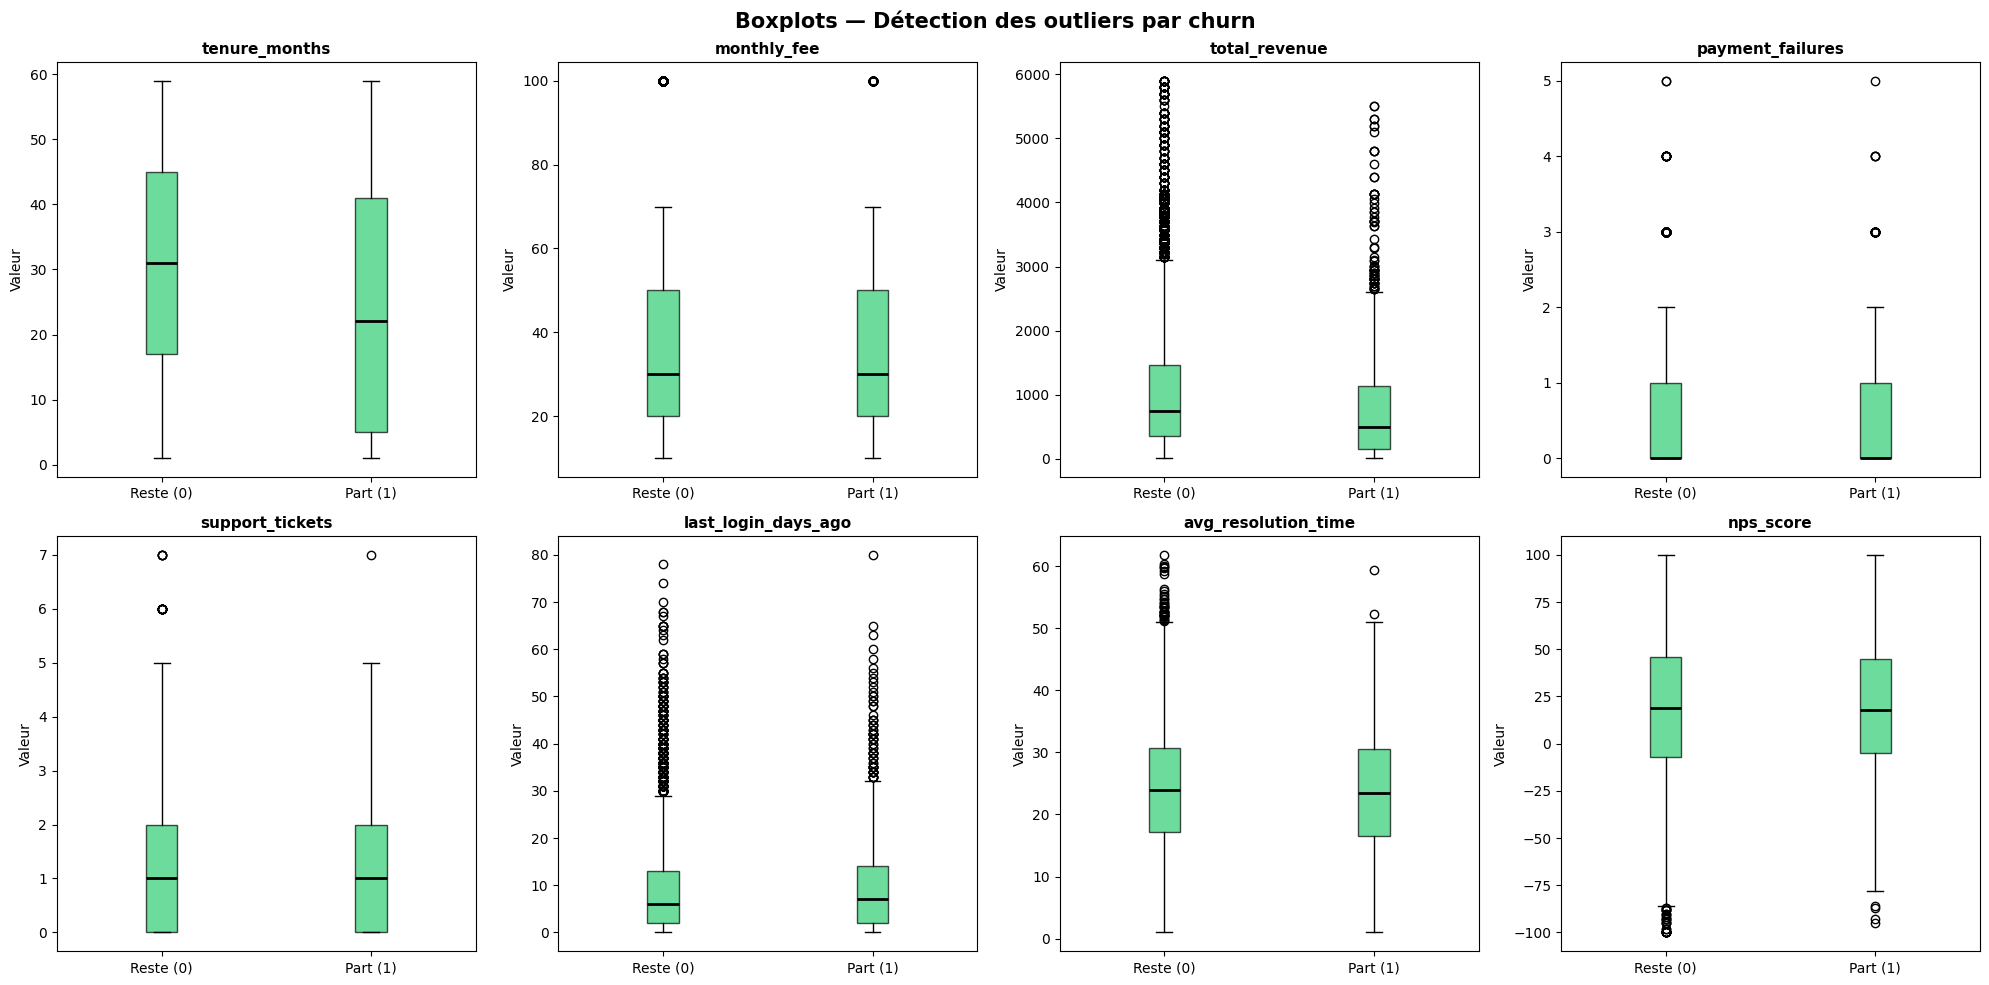

In [16]:

# DÉTECTION DES OUTLIERS
cols_outliers = ['tenure_months', 'monthly_fee', 'total_revenue',
                 'payment_failures', 'support_tickets',
                 'last_login_days_ago', 'avg_resolution_time',
                 'nps_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_outliers):
    data_reste = df[df['churn'] == 0][col]
    data_part = df[df['churn'] == 1][col]
    
    axes[i].boxplot([data_reste, data_part],
                    tick_labels=['Reste (0)', 'Part (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valeur')

plt.suptitle('Boxplots — Détection des outliers par churn',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()  # ← juste ça !

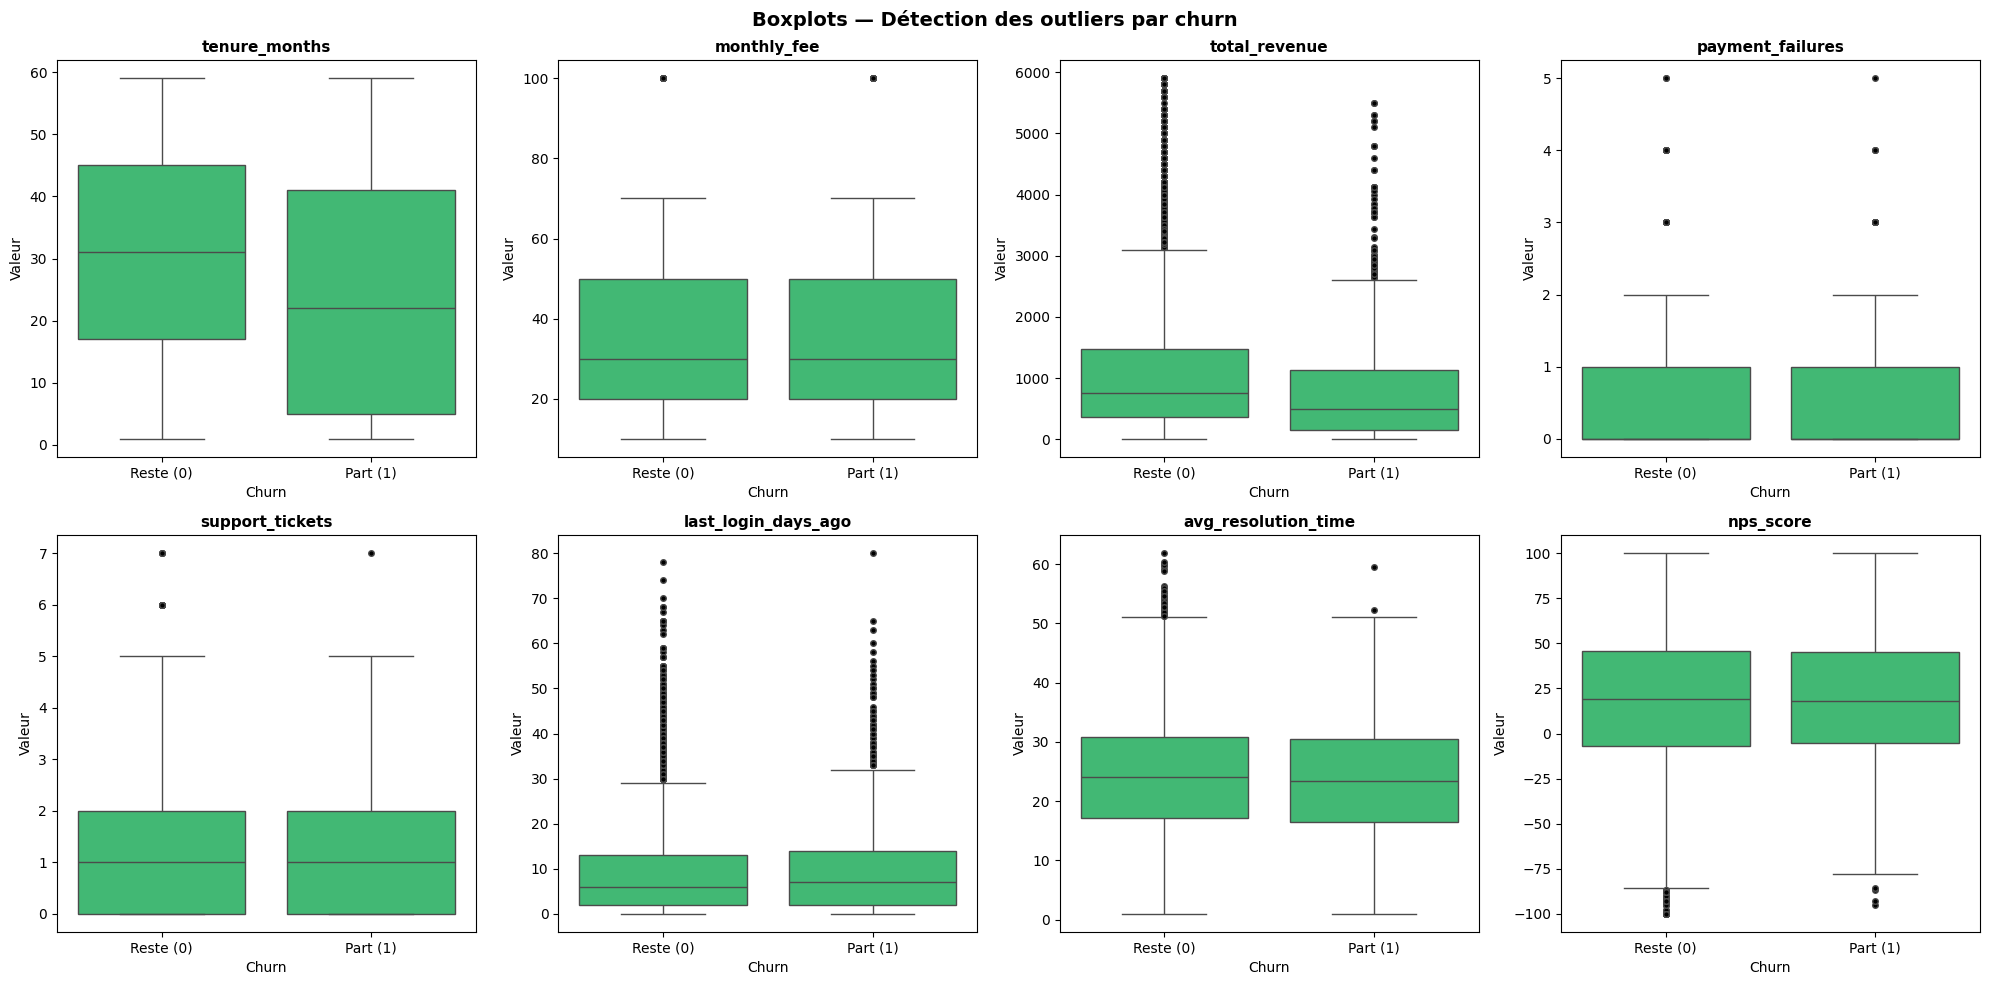

In [17]:
cols_outliers = ['tenure_months', 'monthly_fee', 'total_revenue', 
                 'payment_failures', 'support_tickets', 
                 'last_login_days_ago', 'avg_resolution_time', 'nps_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_outliers):
    sns.boxplot(data=df, x='churn', y=col, ax=axes[i],
                color='#2ecc71',
                flierprops=dict(marker='o', markerfacecolor='black', markersize=4))
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel('Valeur')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Reste (0)', 'Part (1)'])

plt.suptitle('Boxplots — Détection des outliers par churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

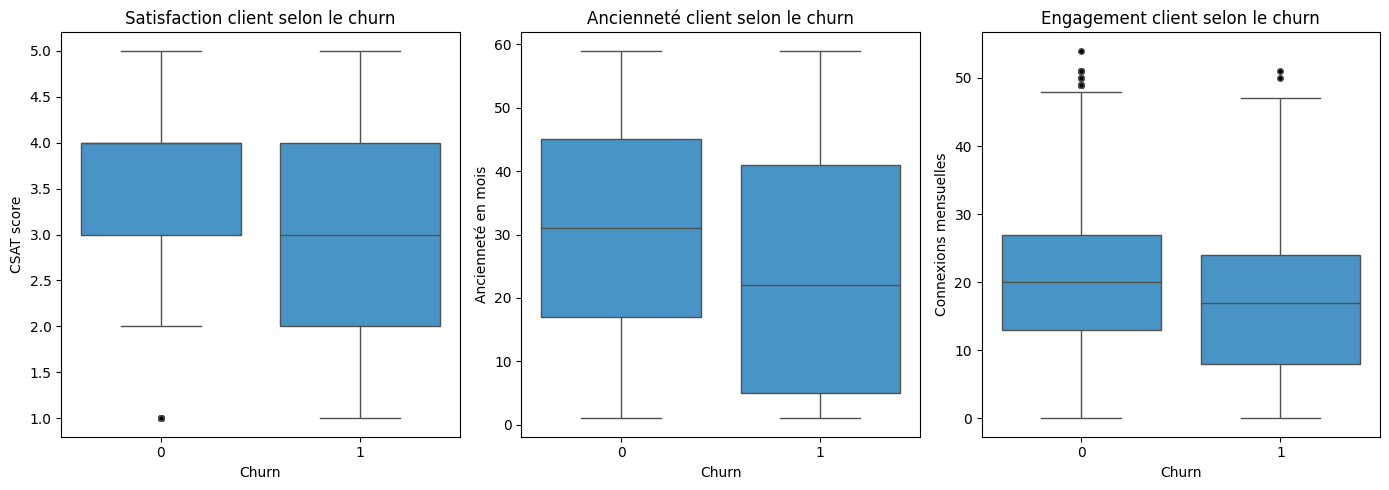

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# csat_score
sns.boxplot(data=df, x='churn', y='csat_score', ax=axes[0], color='#3498db',
            flierprops=dict(marker='o', markerfacecolor='black', markersize=4))
axes[0].set_title('Satisfaction client selon le churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('CSAT score')

# tenure_months
sns.boxplot(data=df, x='churn', y='tenure_months', ax=axes[1], color='#3498db',
            flierprops=dict(marker='o', markerfacecolor='black', markersize=4))
axes[1].set_title('Ancienneté client selon le churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Ancienneté en mois')

# monthly_logins
sns.boxplot(data=df, x='churn', y='monthly_logins', ax=axes[2], color='#3498db',
            flierprops=dict(marker='o', markerfacecolor='black', markersize=4))
axes[2].set_title('Engagement client selon le churn')
axes[2].set_xlabel('Churn')
axes[2].set_ylabel('Connexions mensuelles')

plt.tight_layout()
plt.savefig('../results/eda_boxplots_slide.png', dpi=150, bbox_inches='tight')
plt.show()

## Heatmap croisée — Segment client × Type de contrat

On croise deux variables clés pour identifier les sous-segments 
les plus à risque.

On calcule pour chaque combinaison (segment × contrat) 
le taux de churn moyen.

Insights :
- **SME** : taux le plus élevé sur tous les types de contrat
  (Monthly 11.0%, Quarterly 10.7%, Yearly 11.1%)
- **Enterprise + Quarterly** : combinaison la plus sûre (7.6%)
  → Les grandes entreprises sous contrat trimestriel sont les plus fidèles
- **Individual** : très stable autour de 10% quelle que soit 
  la durée du contrat
- Les écarts restent faibles (7.6% à 11.1%) — aucune combinaison
  ne présente de risque dramatiquement supérieur aux autres

Conclusion : le croisement segment × contrat ne révèle pas 
de sous-segment à très haut risque. Les variables numériques 
restent plus discriminantes pour prédire le churn.

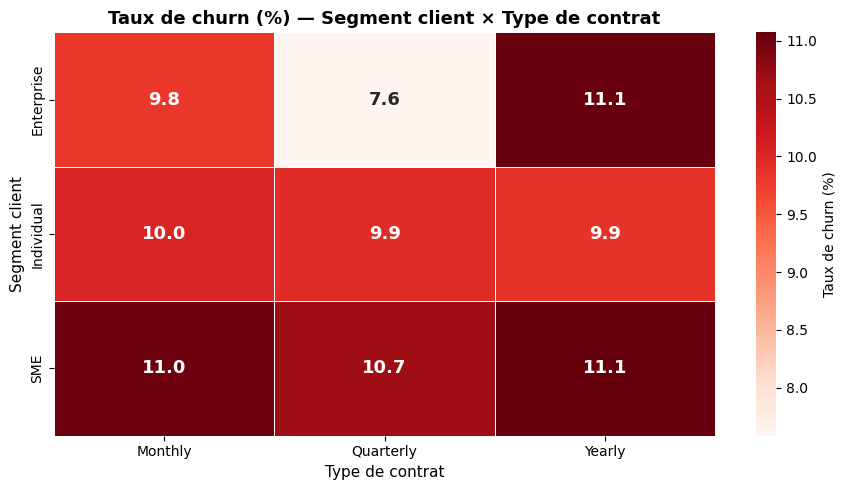

In [19]:
# HEATMAP CROISÉE — SEGMENT × CONTRAT

pivot = df.pivot_table(values='churn',
                       index='customer_segment',
                       columns='contract_type',
                       aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot,
            annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5,
            annot_kws={'size': 13, 'fontweight': 'bold'},
            ax=ax,
            cbar_kws={'label': 'Taux de churn (%)'})

ax.set_title('Taux de churn (%) — Segment client × Type de contrat',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Type de contrat', fontsize=11)
ax.set_ylabel('Segment client', fontsize=11)
plt.tight_layout()
plt.show()


## PARTIE 3 — Analyses spécifiques à la Régression


## Distribution de `revenue_at_risk` — Variable cible Régression

`revenue_at_risk` est la variable qu'on cherche à **prédire** 
avec le modèle de régression.

Elle est construite comme suit : `revenue_at_risk = total_revenue × churn`

Résultats observés :
- **89.8% des valeurs = 0€** : les clients qui ne churnent pas 
  ont un risque nul
- Sur les **1 021 churners**, le revenu à risque va de quelques 
  euros à **5 500€**
- **Moyenne : 845€**, mais **médiane : 490€** → distribution 
  très asymétrique (skewness = 1.95)
- **Revenu total à risque : 862 640€**

La forte asymétrie (skewness = 1.95) et la masse de zéros 
expliquent pourquoi :
1. Le modèle sera entraîné **uniquement sur les churners** (1 021)
   pour éviter de biaiser les prédictions vers 0
2. Une **log-transformation** (np.log1p) sera appliquée pour 
   stabiliser la distribution avant l'entraînement
3. On privilégiera des modèles robustes comme **Random Forest** 
   ou **XGBoost**

C:\Users\ervin\AppData\Local\Temp\ipykernel_44176\2514296910.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ervin\Documents\efrei\data\projet-data-science\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


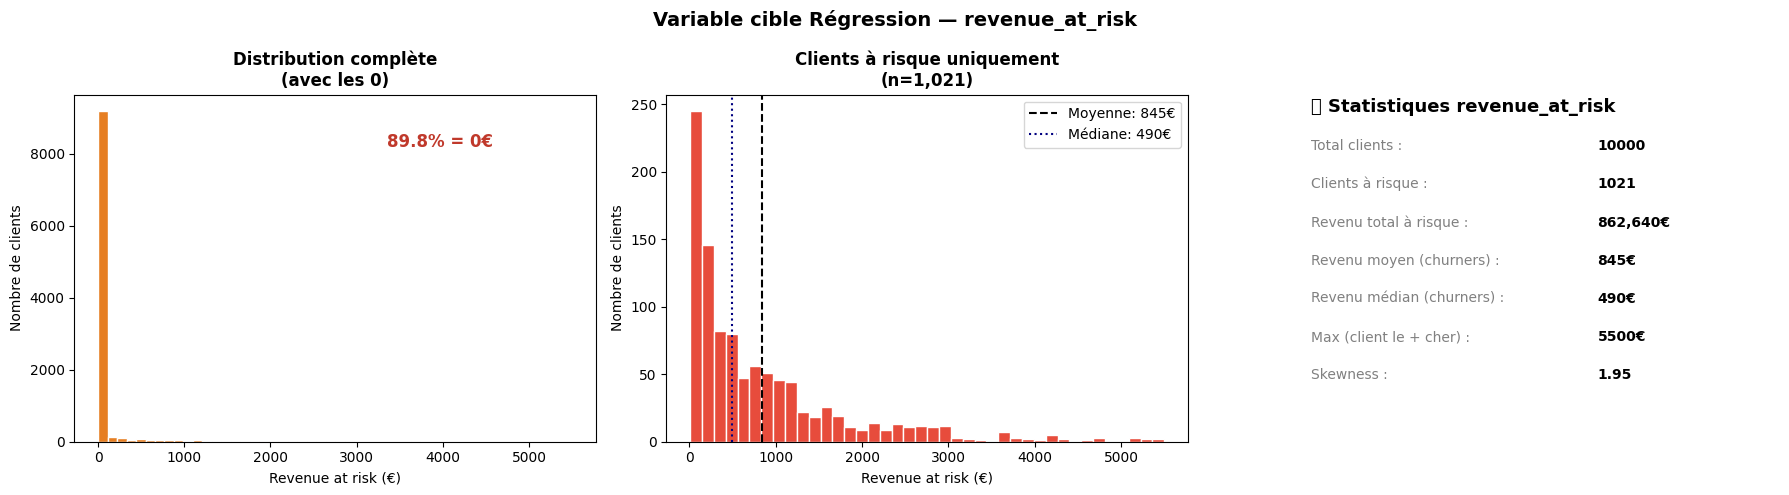

In [20]:
# DISTRIBUTION DE REVENUE_AT_RISK
df['revenue_at_risk'] = df['total_revenue'] * df['churn']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphe 1 — Distribution complète (avec les 0)
axes[0].hist(df['revenue_at_risk'], bins=50,
             color='#e67e22', edgecolor='white')
axes[0].set_title('Distribution complète\n(avec les 0)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Revenue at risk (€)')
axes[0].set_ylabel('Nombre de clients')
zero_pct = (df['revenue_at_risk'] == 0).mean() * 100
axes[0].text(0.6, 0.85, f'{zero_pct:.1f}% = 0€',
             transform=axes[0].transAxes, fontsize=12,
             fontweight='bold', color='#c0392b')

# Graphe 2 — Distribution des clients à risque uniquement (sans les 0)
risk_only = df[df['revenue_at_risk'] > 0]['revenue_at_risk']
axes[1].hist(risk_only, bins=40, color='#e74c3c', edgecolor='white')
axes[1].set_title(f'Clients à risque uniquement\n(n={len(risk_only):,})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Revenue at risk (€)')
axes[1].set_ylabel('Nombre de clients')
axes[1].axvline(risk_only.mean(), color='black', linestyle='--',
                label=f'Moyenne: {risk_only.mean():.0f}€')
axes[1].axvline(risk_only.median(), color='navy', linestyle=':',
                label=f'Médiane: {risk_only.median():.0f}€')
axes[1].legend()

# Graphe 3 — Statistiques clés
stats = {
    'Total clients': len(df),
    'Clients à risque': len(risk_only),
    'Revenu total à risque': f"{df['revenue_at_risk'].sum():,.0f}€",
    'Revenu moyen (churners)': f"{risk_only.mean():.0f}€",
    'Revenu médian (churners)': f"{risk_only.median():.0f}€",
    'Max (client le + cher)': f"{risk_only.max():.0f}€",
    'Skewness': f"{risk_only.skew():.2f}"
}
axes[2].axis('off')
y_pos = 0.95
axes[2].text(0.1, y_pos, '📊 Statistiques revenue_at_risk',
             fontsize=13, fontweight='bold', transform=axes[2].transAxes)
for key, val in stats.items():
    y_pos -= 0.11
    axes[2].text(0.1, y_pos, f'{key} :', fontsize=10,
                 transform=axes[2].transAxes, color='gray')
    axes[2].text(0.65, y_pos, str(val), fontsize=10,
                 transform=axes[2].transAxes, fontweight='bold')

plt.suptitle('Variable cible Régression — revenue_at_risk',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Analyse des churners par valeur financière

Tous les churners ne représentent pas le même risque financier. 
On les segmente en 3 tiers selon leur `revenue_at_risk` :

- **High value** (> 1140€) : les clients dont le départ coûte le plus cher
- **Medium value** (entre 150€ et 1140€) : la majorité des churners
- **Low value** (< 150€) : churners à faible impact financier

Résultats :
- Les **261 clients High Value** concentrent **573 520€** sur 
  862 640€ total → soit **66% du risque** pour seulement 26% 
  des churners
- Les **515 clients Medium Value** représentent **272 510€**
- Les **245 clients Low Value** ne représentent que **16 610€** 
  → priorité de rétention faible
- Profil High Value : ancienneté 42 mois, abonnement 55€/mois 
  → clients fidèles et à forte valeur

**Implication business** : le modèle de régression permet de 
prioriser les actions de rétention sur les 261 clients High Value 
plutôt que de traiter tous les churners de la même façon.

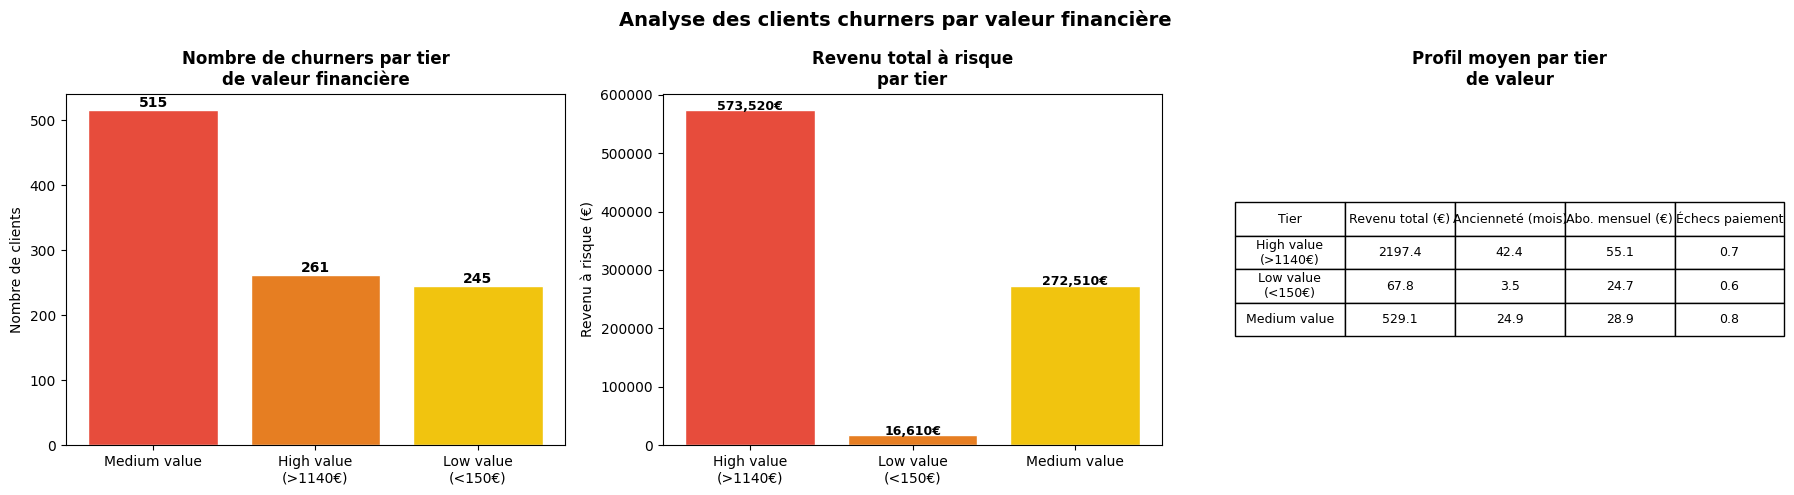


Résumé financier :
   Revenu total à risque       : 862,640€
   Part des High Value churners : 66.5% du risque total
   → Priorité de rétention sur 261 clients pour protéger 573,520€


In [23]:
# ANALYSE DES CLIENTS À FORTE VALEUR FINANCIÈRE

churners = df[df['churn'] == 1].copy()

q75 = churners['revenue_at_risk'].quantile(0.75)
q25 = churners['revenue_at_risk'].quantile(0.25)

def categorize(val):
    if val >= q75:
        return 'High value\n(>' + f'{q75:.0f}€)'
    elif val >= q25:
        return 'Medium value'
    else:
        return 'Low value\n(<' + f'{q25:.0f}€)'

churners['value_tier'] = churners['revenue_at_risk'].apply(categorize)

tier_order = [f'High value\n(>{q75:.0f}€)', 'Medium value', f'Low value\n(<{q25:.0f}€)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphe 1 — Répartition par tier
tier_counts = churners['value_tier'].value_counts()
tier_revenue = churners.groupby('value_tier')['revenue_at_risk'].sum()

colors_tier = ['#e74c3c', '#e67e22', '#f1c40f']
axes[0].bar(tier_counts.index, tier_counts.values, color=colors_tier, edgecolor='white')
axes[0].set_title('Nombre de churners par tier\nde valeur financière', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for j, (idx, v) in enumerate(tier_counts.items()):
    axes[0].text(j, v + 5, str(v), ha='center', fontweight='bold')

# Graphe 2 — Revenu total par tier
axes[1].bar(tier_revenue.index, tier_revenue.values, color=colors_tier, edgecolor='white')
axes[1].set_title('Revenu total à risque\npar tier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenu à risque (€)')
for j, (idx, v) in enumerate(tier_revenue.items()):
    axes[1].text(j, v + 1000, f'{v:,.0f}€', ha='center', fontsize=9, fontweight='bold')

# Graphe 3 — Profil moyen par tier
profil_tier = churners.groupby('value_tier')[['total_revenue', 'tenure_months',
                                               'monthly_fee', 'payment_failures']].mean()
profil_tier = profil_tier.round(1)

axes[2].axis('off')
table_data = profil_tier.reset_index().values.tolist()
col_labels = ['Tier', 'Revenu total (€)', 'Ancienneté (mois)', 'Abo. mensuel (€)', 'Échecs paiement']
table = axes[2].table(cellText=table_data,
                       colLabels=col_labels,
                       loc='center',
                       cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 2.2)
axes[2].set_title('Profil moyen par tier\nde valeur', fontsize=12, fontweight='bold')

plt.suptitle('Analyse des clients churners par valeur financière',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé texte
total_risk = churners['revenue_at_risk'].sum()
high_risk = tier_revenue.get(f'High value\n(>{q75:.0f}€)', 0)
print(f"\nRésumé financier :")
print(f"   Revenu total à risque       : {total_risk:,.0f}€")
print(f"   Part des High Value churners : {high_risk/total_risk*100:.1f}% du risque total")
high_key = f'High value\n(>{q75:.0f}€)'
print(f"   → Priorité de rétention sur {tier_counts[high_key]} clients pour protéger {high_risk:,.0f}€")

# Synthèse de l'EDA

## Ce qu'on a découvert
1. **Déséquilibre** : 89.8% restent vs 10.2% partent
2. **Nouveaux clients** à risque : tenure_months bas = plus de churn
3. **Signaux forts** : csat_score (-0.16), tenure_months (-0.12), 
   payment_failures (+0.11), monthly_logins (-0.10)
4. **Variables catégorielles** : aucun segment discriminant fort — 
   tous les taux restent entre 9% et 11.5%
5. **Corrélation forte** : monthly_fee ↔ total_revenue (0.71)
6. **Valeurs manquantes** : complaint_type (2045) → "No_Complaint"
7. **Outliers** : conservés car signaux business réels

## Décisions pour le Preprocessing (étape suivante)
1. Supprimer `customer_id` et `city` (inutiles pour la prédiction)
2. Remplir `complaint_type` manquants par "No_Complaint"
3. Encoder les 12 variables catégorielles (OneHotEncoder)
4. Normaliser les variables numériques (StandardScaler)
5. Gérer le déséquilibre : comparer Undersampling, SMOTE 
   et class_weight='balanced'
6. Séparer Train (80%) / Test (20%) de façon stratifiée